# AG-HYPOPT · Trial 02

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Registry now holds one trial: trial_01 (sigma_ref 23.97, lr_mu 8.60, lr_gamma 0.960, gamma_anneal 0.384) -> objective 0.1907 +/- 0.0310, currently the best (and only) recorded trial. Its outcome was a uniform ~half-truth attractor in mu on all 8 experiments, with gamma recovered only at high transmission. The proposer is still in the uniform warm-up phase (1/5 completed), so candidates remain independent uniform draws with no exploitable ranking information. Context only.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_02'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = uniform  (1/5 trials)
ID |     ei | params
 1 |      - | {"gamma_anneal": 0.1962091006869873, "lr_gamma": 0.43879291473129867, "lr_mu": 25.355643514857007, "sigma_ref": 6.838318842701938}
 2 |      - | {"gamma_anneal": 0.4500753944742405, "lr_gamma": 0.7828484214494358, "lr_mu": 9.697526834165085, "sigma_ref": 6.102932546661364}
 3 |      - | {"gamma_anneal": 0.20622702592952857, "lr_gamma": 0.7259464119004742, "lr_mu": 19.056641569510703, "sigma_ref": 8.001245266106721}
 4 |      - | {"gamma_anneal": 0.3244730931035904, "lr_gamma": 0.7354378388596163, "lr_mu": 15.569616831753196, "sigma_ref": 17.663687985482326}
 5 |      - | {"gamma_anneal": 0.7255769643702574, "lr_gamma": 0.7464518578477002, "lr_mu": 14.790620827000653, "sigma_ref": 8.745051394401962}
 6 |      - | {"gamma_anneal": 0.25947049917879983, "lr_gamma": 0.6088527788556617, "lr_mu": 27.28023523751448, "sigma_ref": 20.511278849453788}
 7 |      - | {"gamma_anneal": 0.23860995046153077, "lr_gamma": 0.9393735172054594

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Only one completed trial exists (trial_01, objective 0.1907) and the proposer is still in the uniform warm-up phase (1/5), so there is no exploiter/interpreter model in play and the candidates are still independent uniform draws -- they carry no ranking signal. With nothing to discriminate between them, I take the first enumerated proposal. I choose candidate 1.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 1               # first candidate (uniform phase, no ranking signal)


chosen: {'gamma_anneal': 0.1962091006869873, 'lr_gamma': 0.43879291473129867, 'lr_mu': 25.355643514857007, 'sigma_ref': 6.838318842701938}
Running  1nW Trans05 ... 

μ 9.39 -> 5.11 | γ 8.5 -> 6.44 | NLL 1.31


Running  1nW Trans20 ... 

μ 17.32 -> 8.92 | γ 8.5 -> 4.04 | NLL 3.47


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 37.03 | γ 14.1 -> 12.50 | NLL 3.14


Running 3nW Trans100 ... 

μ 175.71 -> 54.28 | γ 14.1 -> 12.46 | NLL 2.89



Total: 2.3 min


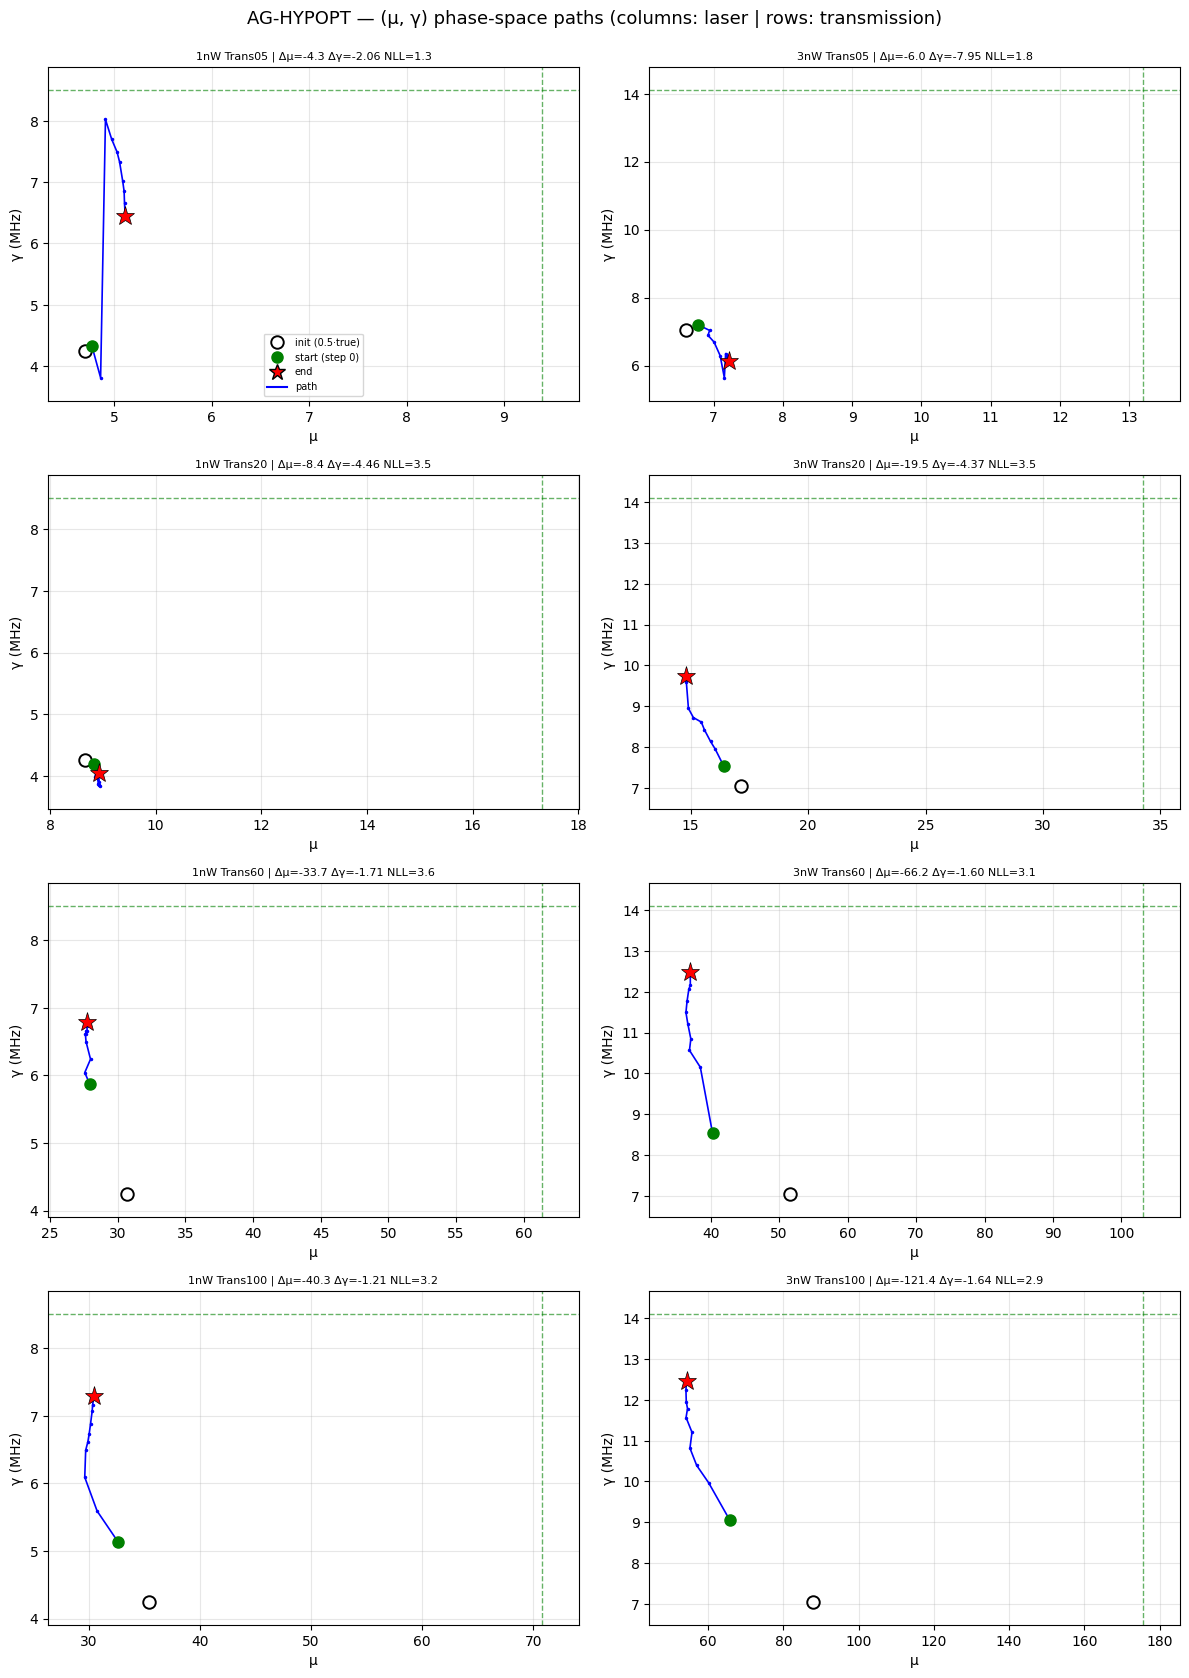

trial finished in 2.4 min
objective = 0.2075 ± 0.0377
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    5.11   -45.6 |     8.50    6.44   -24.2
1nW Trans20    17.32    8.92   -48.5 |     8.50    4.04   -52.5
1nW Trans60    61.37   27.70   -54.9 |     8.50    6.79   -20.1
1nW Trans100   70.82   30.48   -57.0 |     8.50    7.29   -14.2
3nW Trans05    13.20    7.22   -45.3 |    14.10    6.15   -56.4
3nW Trans20    34.28   14.82   -56.8 |    14.10    9.73   -31.0
3nW Trans60   103.20   37.03   -64.1 |    14.10   12.50   -11.4
3nW Trans100  175.71   54.28   -69.1 |    14.10   12.46   -11.6

μ: RMSE 52.901 (rel 55.7%, bias -37.467) | γ: RMSE 3.809 (rel 32.3%, bias -3.124)


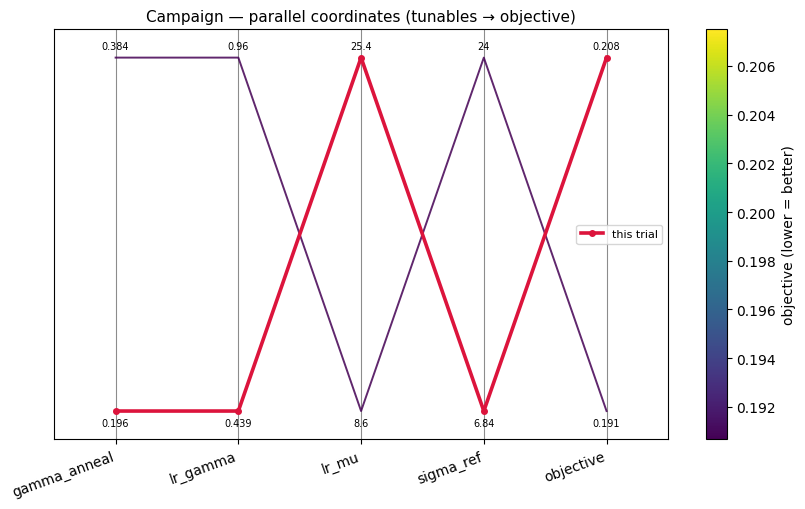

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 02, second trial; proposer still in the uniform warm-up phase (1/5), so config is again an uninformative random draw: sigma_ref 6.84, lr_mu 25.36, lr_gamma 0.439, gamma_anneal 0.196. Result: objective 0.2075 +/- 0.0377 (slightly worse than trial_01's 0.1907), runtime 2.4 min. mu_fit is again far below mu_true but now scattered rather than uniform: Delta-mu% ranges -45.3 to -69.1 (worst at high transmission, 3 nW Trans60/100: -64.1/-69.1), giving mu RMSE 52.90 (relative 55.7%, bias -37.5) -- worse than trial_01. gamma_fit remains near-truth at high transmission (3 nW Trans60/100: -11.4%/-11.6%; 1 nW Trans100: -14.2%) and collapsed at low/mid transmission (1 nW Trans20 -52.5%, 3 nW Trans05 -56.4%); gamma RMSE 3.81 (relative 32.3%, bias -3.1), marginally better than trial_01's 3.97. So relative to the only previous trial, the mu term degraded and the gamma term improved a touch, for a net slightly higher objective.

**Summary:** Trial 02 (sigma_ref 6.84, lr_mu 25.36, lr_gamma 0.439, gamma_anneal 0.196) -> objective 0.2075 +/- 0.0377, slightly worse than trial_01; the mu attractor persists but scatters to -45..-69% while gamma stays good only at high transmission.
**Key insight:** The ~half-truth mu attractor is robust to this more aggressive lr_mu/low sigma_ref config (indeed the mu gap widens at high transmission), while gamma's low-transmission collapse is the other persistent loss contributor.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
No new structural notes; the trial_01 note on the real-data attractor still stands.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 02 (sigma_ref 6.84, lr_mu 25.36, lr_gamma 0.439, gamma_anneal 0.196): objective 0.2075 +/- 0.0377, slightly worse than trial_01; mu gap -45..-69%, gamma good only at high transmission'
KEY_INSIGHT = 'The ~half-truth mu attractor is robust to a more aggressive lr_mu / low sigma_ref config (the mu gap even widens at high transmission); gamma low-transmission collapse is the other persistent loss contributor.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_02 | current best: trial_01


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_03.ipynb. Open it and follow its cells from the top.
